# 03 - Model Development and Evaluation

**Part A - Population architecture**

This part constructs and verifies the populations used for model development and
evaluation.  Its purpose is to establish that the populations described in Methodology
Section 3.5 exist exactly as designed, and to produce the counts reported there.

The architecture is:

- the earliest temporal cohort is divided at patient level into a **model-development
  subset** and a **same-era holdout**;
- the model-development subset is the only data used to fit anything;
- the fixed pipeline is then evaluated on three populations of unseen patients - the
  same-era holdout, and the patients in each later period who appear nowhere in the
  earliest cohort;
- the full later cohorts, and the returning patients within them, are retained for
  sensitivity analysis only.

Input: noar_prediction_pairs.csv from 01_data_audit_and_preparation.ipynb.

In [ ]:
%pip install xgboost optuna
%pip install shap

## A1. Load and integrity checks

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

SEED = 42                    # fixed in advance; not selected by inspecting splits
N_SPLITS = 4                 # one fold held out => 25% same-era holdout
HOLDOUT_FOLD = 0             # designated in advance

pairs = pd.read_csv('noar_prediction_pairs.csv')

assert len(pairs) == 10323, f'expected 10,323 pairs, found {len(pairs):,}'
assert pairs.regno.nunique() == 2279, f'expected 2,279 patients, found {pairs.regno.nunique():,}'
assert pairs.y.isin([0, 1]).all() and pairs.y.notna().all(), 'target is not clean binary'
assert pairs.cohort.notna().all(), 'unassigned cohort present'
assert not pairs.duplicated(['regno', 'fupno']).any(), 'duplicate prediction pair'

print(f'pairs    : {len(pairs):,}')
print(f'patients : {pairs.regno.nunique():,}')
print(f'active   : {pairs.y.sum():,} ({pairs.y.mean()*100:.1f}%)')

pairs    : 10,323
patients : 2,279
active   : 4,877 (47.2%)


## A2. Feature specification

Twelve predictors, fixed in Section 3.4. Ethnicity is retained in the data for
descriptive reporting but is not a predictor. Columns that identify the patient, encode
the calendar period, or describe the outcome visit are named explicitly so that no
feature matrix is ever built by dropping the target alone.

In [3]:
MODEL_CONTINUOUS = ['agefu', 'disease_duration', 'bmi', 'tend_28jt', 'swollen_28jt',
                    'esr_score', 'Days_on_Steroids', 'Days_on_DMARDs',
                    'comorbidity_count']
MODEL_CATEGORICAL = ['gender', 'sc', 'biologic_exposed']
MODEL_FEATURES = MODEL_CONTINUOUS + MODEL_CATEGORICAL

TARGET, GROUP = 'y', 'regno'

NON_MODEL_COLUMNS = ['y', 'y_next', 'das_next', 'year_next', 'gap', 'das28',
                     'disease_activity', 'cohort', 'regno', 'fupno', 'follow_up_year',
                     'follow_up_year_original', 'regyear', 'ethnicity', 'died',
                     'yeardied', 'dead_status', 'censored_status', 'Days_on_Biologics',
                     'smokestatus', 'crpscore', 'height', 'weight']

assert len(MODEL_FEATURES) == 12, f'expected 12 predictors, got {len(MODEL_FEATURES)}'
assert not set(MODEL_FEATURES) & set(NON_MODEL_COLUMNS), 'non-model column in MODEL_FEATURES'
assert not set(MODEL_FEATURES) - set(pairs.columns), 'predictor absent from the data'

print(f'predictors : {len(MODEL_FEATURES)} '
      f'({len(MODEL_CONTINUOUS)} continuous, {len(MODEL_CATEGORICAL)} categorical)')
print(f'target     : {TARGET}   grouping variable: {GROUP}')

predictors : 12 (9 continuous, 3 categorical)
target     : y   grouping variable: regno


## A3. Temporal cohorts

Verified against the values established in Notebook 01.

In [4]:
COHORTS = ['<=2007', '2008-2011', '2012+']
EXPECTED = {'<=2007': 3364, '2008-2011': 3888, '2012+': 3071}

obs = pairs.cohort.value_counts().to_dict()
for k, v in EXPECTED.items():
    assert obs.get(k) == v, f'cohort {k}: expected {v:,}, found {obs.get(k):,}'
assert sum(EXPECTED.values()) == len(pairs), 'cohorts do not sum to the analytic sample'

summary = (pairs.groupby('cohort', observed=True)
                .agg(pairs=(TARGET, 'size'), patients=(GROUP, 'nunique'),
                     active=(TARGET, 'sum'))
                .reindex(COHORTS))
summary['active_pct'] = (summary.active / summary.pairs * 100).round(1)
print(summary.to_string())
print(f'\npredictor-visit years: {int(pairs.follow_up_year.min())}'
      f'-{int(pairs.follow_up_year.max())}')

           pairs  patients  active  active_pct
cohort                                        
<=2007      3364      1199    1843        54.8
2008-2011   3888      1680    1866        48.0
2012+       3071      1680    1168        38.0

predictor-visit years: 2000-2016


## A4. The earliest-cohort patient set

Every patient appearing anywhere in the earliest cohort is included in this set. A later primary evaluation population is patient-disjoint only if none of its patients appears in the earliest-cohort set. Defining disjointness against the whole earliest cohort rather than the model-development subset ensures that later evaluation patients were absent from the entire earliest period, not merely unseen during model fitting.

In [5]:
earliest = pairs[pairs.cohort == '<=2007'].copy()
earliest_patients = set(earliest[GROUP])

print(f'earliest cohort  : {len(earliest):,} pairs, {len(earliest_patients):,} patients')
print(f'active           : {earliest.y.sum():,} ({earliest.y.mean()*100:.2f}%)')

spans = pairs.groupby(GROUP, observed=True).cohort.nunique()
print(f'\npatients appearing in more than one cohort: {(spans > 1).sum():,} '
      f'({(spans > 1).mean()*100:.1f}%)')
for c in COHORTS[1:]:
    g = pairs[pairs.cohort == c]
    ret = g[g[GROUP].isin(earliest_patients)]
    print(f'  {c:10s} {ret[GROUP].nunique():,} patients also in the earliest cohort, '
          f'contributing {len(ret):,} of {len(g):,} pairs ({len(ret)/len(g)*100:.1f}%)')

earliest cohort  : 3,364 pairs, 1,199 patients
active           : 1,843 (54.79%)

patients appearing in more than one cohort: 1,499 (65.8%)
  2008-2011  1,059 patients also in the earliest cohort, contributing 2,680 of 3,888 pairs (68.9%)
  2012+      796 patients also in the earliest cohort, contributing 1,430 of 3,071 pairs (46.6%)


## A5. Development and same-era holdout

The earliest cohort is divided at patient level. `StratifiedGroupKFold` keeps every pair
belonging to a patient in the same part while attempting to preserve the outcome
proportion; it does not guarantee equality, so the realised prevalence is reported rather
than assumed. The seed and the designated holdout fold are fixed in advance.

In [6]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(sgkf.split(earliest, earliest[TARGET], groups=earliest[GROUP]))
dev_idx, hold_idx = folds[HOLDOUT_FOLD][0], folds[HOLDOUT_FOLD][1]

development = earliest.iloc[dev_idx].copy()
holdout     = earliest.iloc[hold_idx].copy()

dev_patients  = set(development[GROUP])
hold_patients = set(holdout[GROUP])

assert not dev_patients & hold_patients, 'patient appears in both development and holdout'
assert len(development) + len(holdout) == len(earliest), 'split does not reconstruct the cohort'
assert dev_patients | hold_patients == earliest_patients, 'patients lost in the split'

for lab, s in [('earliest cohort', earliest), ('  development', development),
               ('  same-era holdout', holdout)]:
    print(f'{lab:20s} {len(s):5,} pairs  {s[GROUP].nunique():5,} patients  '
          f'{int(s.y.sum()):5,} active  {int((1-s.y).sum()):5,} inactive  '
          f'{s.y.mean()*100:5.2f}% active')
print(f'\nholdout share of pairs    : {len(holdout)/len(earliest)*100:.1f}%')
print(f'holdout share of patients : {len(hold_patients)/len(earliest_patients)*100:.1f}%')
print(f'patient overlap           : {len(dev_patients & hold_patients)}')

earliest cohort      3,364 pairs  1,199 patients  1,843 active  1,521 inactive  54.79% active
  development        2,523 pairs    896 patients  1,382 active  1,141 inactive  54.78% active
  same-era holdout     841 pairs    303 patients    461 active    380 inactive  54.82% active

holdout share of pairs    : 25.0%
holdout share of patients : 25.3%
patient overlap           : 0


## A6. Later evaluation populations

For each later period, the primary evaluation population is the pairs contributed by
patients absent from the entire earliest cohort. The returning patients form the
complement and are retained for sensitivity analysis only.

In [7]:
populations = {}
for c in COHORTS[1:]:
    g = pairs[pairs.cohort == c]
    new = g[~g[GROUP].isin(earliest_patients)].copy()
    ret = g[g[GROUP].isin(earliest_patients)].copy()

    assert len(new) + len(ret) == len(g), f'{c}: new and returning do not reconstruct the cohort'
    assert not set(new[GROUP]) & earliest_patients, f'{c}: earliest-cohort patient in the patient-disjoint set'
    assert not set(new[GROUP]) & set(ret[GROUP]), f'{c}: patient in both new and returning'

    populations[c] = {'full': g, 'new': new, 'returning': ret}
    print(f'{c}')
    print(f'  full cohort        {len(g):5,} pairs  {g[GROUP].nunique():5,} patients  '
          f'{g.y.mean()*100:5.2f}% active')
    print(f'  patient-disjoint       {len(new):5,} pairs  {new[GROUP].nunique():5,} patients  '
          f'{new.y.mean()*100:5.2f}% active   <- primary')
    print(f'  returning patients {len(ret):5,} pairs  {ret[GROUP].nunique():5,} patients  '
          f'{ret.y.mean()*100:5.2f}% active   <- sensitivity')

assert not set(populations['2008-2011']['new'][GROUP]) & earliest_patients
assert not set(populations['2012+']['new'][GROUP]) & earliest_patients
print('\nAll disjointness assertions passed.')

2008-2011
  full cohort        3,888 pairs  1,680 patients  47.99% active
  patient-disjoint       1,208 pairs    621 patients  47.19% active   <- primary
  returning patients 2,680 pairs  1,059 patients  48.36% active   <- sensitivity
2012+
  full cohort        3,071 pairs  1,680 patients  38.03% active
  patient-disjoint       1,641 pairs    884 patients  35.59% active   <- primary
  returning patients 1,430 pairs    796 patients  40.84% active   <- sensitivity

All disjointness assertions passed.


## A7. Population architecture audit

One table describing every population, its role and its size. This is the factual basis
for Methodology Table 3.2.

In [8]:
def row(name, period, role, s):
    return {'Population': name, 'Period': period, 'Role': role,
            'Pairs': len(s), 'Patients': s[GROUP].nunique(),
            'Active': int(s.y.sum()), 'Inactive': int((1 - s.y).sum()),
            'Active %': round(s.y.mean() * 100, 1)}

arch = pd.DataFrame([
    row('Earliest temporal cohort', '<=2007', 'Source population', earliest),
    row('  Model-development subset', '<=2007', 'Model fitting and tuning', development),
    row('  Same-era holdout', '<=2007', 'Primary evaluation (contemporaneous)', holdout),
    row('Second temporal cohort', '2008-2011', 'Source population',
        populations['2008-2011']['full']),
    row('  patient-disjoint', '2008-2011', 'Primary evaluation',
        populations['2008-2011']['new']),
    row('  Returning patients', '2008-2011', 'Sensitivity analysis',
        populations['2008-2011']['returning']),
    row('Third temporal cohort', '2012+', 'Source population',
        populations['2012+']['full']),
    row('  patient-disjoint', '2012+', 'Primary evaluation', populations['2012+']['new']),
    row('  Returning patients', '2012+', 'Sensitivity analysis',
        populations['2012+']['returning']),
])

arch.to_csv('population_architecture.csv', index=False)
print('Population architecture')
display(arch)

print(f'\nfitting data      : {len(development):,} pairs from {development[GROUP].nunique():,} patients')
print(f'evaluation data   : {len(holdout) + len(populations["2008-2011"]["new"]) + len(populations["2012+"]["new"]):,} '
      f'pairs across three populations of unseen patients')
print(f'seed              : {SEED} (fixed in advance)')

Population architecture


,Population,Period,Role,Pairs,Patients,Active,Inactive,Active %
0,Earliest temporal cohort,<=2007,Source population,3364,1199,1843,1521,54.8
1,Model-development subset,<=2007,Model fitting and tuning,2523,896,1382,1141,54.8
2,Same-era holdout,<=2007,Primary evaluation (contemporaneous),841,303,461,380,54.8
3,Second temporal cohort,2008-2011,Source population,3888,1680,1866,2022,48.0
4,patient-disjoint,2008-2011,Primary evaluation,1208,621,570,638,47.2
5,Returning patients,2008-2011,Sensitivity analysis,2680,1059,1296,1384,48.4
6,Third temporal cohort,2012+,Source population,3071,1680,1168,1903,38.0
7,patient-disjoint,2012+,Primary evaluation,1641,884,584,1057,35.6
8,Returning patients,2012+,Sensitivity analysis,1430,796,584,846,40.8



fitting data      : 2,523 pairs from 896 patients
evaluation data   : 3,690 pairs across three populations of unseen patients
seed              : 42 (fixed in advance)


# Part B — Model development

Three models are developed on the model-development subset alone: a random forest,
pre-specified as the primary analytical model; XGBoost as a boosting-based comparator;
and logistic regression as a transparent benchmark.

Random forest is pre-specified rather than selected on performance. With 2,523 prediction
pairs from 896 patients and twelve predictors, it offers an appropriate compromise between
flexibility and parsimony, works naturally with TreeSHAP, and has a tuning space small
enough to be refitted consistently across the robustness analyses. 

All preprocessing is fitted inside each training fold, so no information from a validation
fold influences imputation or scaling. Hyperparameters are selected by patient-grouped
cross-validation within the development subset. The same-era holdout plays no part in this
section.

# B1. Setup, preprocessing and cross-validation 

In [9]:
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss

import optuna
from xgboost import XGBClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

CV_SPLITS = 5

X_dev = development[MODEL_FEATURES].copy()
y_dev = development[TARGET].to_numpy()
g_dev = development[GROUP].to_numpy()

print(f'development subset : {len(X_dev):,} pairs, {development[GROUP].nunique():,} patients')
print(f'outcome            : {y_dev.mean()*100:.2f}% active')
print(f'holdout            : reserved, not used in this part')


def make_preprocessor(scale):
    """Median-impute continuous predictors (scaled only where the model needs it);
    mode-impute and one-hot encode categorical predictors. Fitted inside each fold."""
    cont = [('impute', SimpleImputer(strategy='median'))]
    if scale:
        cont.append(('scale', StandardScaler()))
    return ColumnTransformer(
        [('continuous', Pipeline(cont), MODEL_CONTINUOUS),
         ('categorical', Pipeline([
             ('impute', SimpleImputer(strategy='most_frequent')),
             ('encode', OneHotEncoder(handle_unknown='ignore', drop='if_binary',
                                      sparse_output=False))]), MODEL_CATEGORICAL)],
        remainder='drop', verbose_feature_names_out=False)


cv = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
print(f'\ntuning CV: {CV_SPLITS}-fold StratifiedGroupKFold grouped by patient, seed {SEED}')

development subset : 2,523 pairs, 896 patients
outcome            : 54.78% active
holdout            : reserved, not used in this part

tuning CV: 5-fold StratifiedGroupKFold grouped by patient, seed 42


In [10]:
lr_pipe = Pipeline([('prep', make_preprocessor(scale=True)),
                    ('model', LogisticRegression(max_iter=5000, solver='liblinear',
                                                 random_state=SEED))])

lr_grid = {'model__C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
           'model__penalty': ['l1', 'l2']}

lr_search = GridSearchCV(lr_pipe, lr_grid, scoring='roc_auc', cv=cv, n_jobs=-1, refit=True)
lr_search.fit(X_dev, y_dev, groups=g_dev)

print('logistic regression')
print(f'  best params : {lr_search.best_params_}')
print(f'  CV AUC      : {lr_search.best_score_:.4f}')

logistic regression
  best params : {'model__C': 0.03, 'model__penalty': 'l1'}
  CV AUC      : 0.8362


## B3. Random forest — primary model

Tuned over tree depth, minimum leaf size and the number of features considered per split.
The number of trees was fixed at 500 to provide stable ensemble estimates while limiting computation, rather than treated as a performance-tuned hyperparameter.

In [11]:
rf_pipe = Pipeline([('prep', make_preprocessor(scale=False)),
                    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))])

rf_grid = {'model__n_estimators': [500],
           'model__max_depth': [None, 8, 12],
           'model__min_samples_leaf': [1, 5, 10, 20],
           'model__max_features': ['sqrt', 0.5]}

rf_search = GridSearchCV(rf_pipe, rf_grid, scoring='roc_auc', cv=cv, n_jobs=-1, refit=True)
rf_search.fit(X_dev, y_dev, groups=g_dev)

print('random forest (primary)')
print(f'  best params : {rf_search.best_params_}')
print(f'  CV AUC      : {rf_search.best_score_:.4f}')

random forest (primary)
  best params : {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 5, 'model__n_estimators': 500}
  CV AUC      : 0.8447


## B4. XGBoost — comparator

The boosting search space is larger than the forest's, so hyperparameters are selected using 40 Optuna TPE trials rather than exhaustive grid search. Each trial is scored by the same patient-grouped cross-validation, with preprocessing refitted inside every fold. The sampler seed is fixed.

In [12]:
def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 200, 900, step=100),
        max_depth=trial.suggest_int('max_depth', 2, 6),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True))

    pipe = Pipeline([('prep', make_preprocessor(scale=False)),
                     ('model', XGBClassifier(**params, random_state=SEED, n_jobs=1,
                                             eval_metric='logloss', tree_method='hist'))])
    scores = []
    for tr, va in cv.split(X_dev, y_dev, groups=g_dev):
        pipe.fit(X_dev.iloc[tr], y_dev[tr])
        scores.append(roc_auc_score(y_dev[va], pipe.predict_proba(X_dev.iloc[va])[:, 1]))
    return float(np.mean(scores))


study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(xgb_objective, n_trials=40, show_progress_bar=False)

print('XGBoost')
print(f'  trials      : {len(study.trials)}')
print(f'  CV AUC      : {study.best_value:.4f}')
print(f'  best params : {study.best_params}')

xgb_pipe = Pipeline([('prep', make_preprocessor(scale=False)),
                     ('model', XGBClassifier(**study.best_params, random_state=SEED,
                                             n_jobs=1, eval_metric='logloss',
                                             tree_method='hist'))])

XGBoost
  trials      : 40
  CV AUC      : 0.8455
  best params : {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01060078643959912, 'subsample': 0.686735172473941, 'colsample_bytree': 0.8987891700507222, 'min_child_weight': 17, 'reg_lambda': 0.02005840759378339, 'reg_alpha': 0.39602180912940044}


## B5. Final fitting and freezing

Each model is refitted on the complete development subset using its selected
hyperparameters, and the fitted pipelines — preprocessing and estimator together — are
saved. Nothing beyond this point alters them: the same objects are applied unchanged to
every evaluation population and are the objects explained in the SHAP analysis.

In [13]:
FITTED = {'Logistic regression': lr_search.best_estimator_,
          'Random forest': rf_search.best_estimator_,
          'XGBoost': xgb_pipe}
PRIMARY = 'Random forest'

for name, pipe in FITTED.items():
    pipe.fit(X_dev, y_dev)

joblib.dump({'models': FITTED, 'primary': PRIMARY, 'features': MODEL_FEATURES,
             'seed': SEED, 'cv_splits': CV_SPLITS}, 'frozen_models.joblib')

for name, pipe in FITTED.items():
    role = 'primary' if name == PRIMARY else 'comparator'
    print(f'{name:22s} {role:11s} refitted on {len(X_dev):,} development pairs')
print('\nfrozen pipelines saved to frozen_models.joblib')

Logistic regression    comparator  refitted on 2,523 development pairs
Random forest          primary     refitted on 2,523 development pairs
XGBoost                comparator  refitted on 2,523 development pairs

frozen pipelines saved to frozen_models.joblib


## B6. Development-set cross-validated tuning summary

Out-of-fold predictions from the same patient-grouped cross-validation, summarised as
discrimination and probabilistic accuracy. The Brier skill score expresses the Brier score relative to a prediction equal to the population's own event prevalence, so that a value of 0 indicates no improvement on the base rate and 1 indicates perfect prediction; it is used because the raw Brier score is influenced by outcome prevalence, which complicates direct comparison across populations with different event rates.

These are development estimates produced using the same folds on which hyperparameters were selected, so they are a tuning summary rather than an unbiased estimate of generalisation performance. Evaluation begins with the untouched same-era holdout.

In [14]:
def brier_skill(y_true, p):
    """Brier score relative to a prediction equal to the population's own prevalence."""
    ref = np.full_like(p, np.mean(y_true), dtype=float)
    return 1 - brier_score_loss(y_true, p) / brier_score_loss(y_true, ref)


rows = []
for name, pipe in FITTED.items():
    oof = cross_val_predict(pipe, X_dev, y_dev, cv=cv, groups=g_dev,
                            method='predict_proba', n_jobs=-1)[:, 1]
    rows.append({'Model': name,
                 'Role': 'Primary' if name == PRIMARY else 'Comparator',
                 'CV ROC-AUC': round(roc_auc_score(y_dev, oof), 3),
                 'CV Brier': round(brier_score_loss(y_dev, oof), 3),
                 'CV Brier skill': round(brier_skill(y_dev, oof), 3)})

cv_table = pd.DataFrame(rows)
cv_table.to_csv('development_cv_performance.csv', index=False)

print('Development-set cross-validated tuning summary')
display(cv_table)


Development-set cross-validated tuning summary


,Model,Role,CV ROC-AUC,CV Brier,CV Brier skill
0,Logistic regression,Comparator,0.835,0.172,0.305
1,Random forest,Primary,0.843,0.161,0.352
2,XGBoost,Comparator,0.844,0.160,0.355


## Part C — Temporal performance evaluation

The pipelines frozen in Part B are evaluated without refitting, recalibration or re-estimation of preprocessing on the same-era holdout and the two later patient-disjoint populations. Preprocessing remains fixed from the development subset, so no evaluation population contributes to model fitting or imputation.

The same-era holdout provides the contemporaneous out-of-sample baseline against which later-period performance is compared.

Uncertainty is estimated using a patient-clustered bootstrap, resampling patients rather than individual prediction pairs to preserve repeated measurements within patients. The Brier skill reference is recomputed within each bootstrap replicate using that replicate's outcome prevalence.

For between-period comparisons, which are valid because the populations are patient-disjoint, patients are resampled independently within each and metric differences are calculated as later period minus same-era holdout. Negative differences therefore indicate lower performance in the later period.

In [15]:
# C1. Load frozen models and define evaluation populations
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

N_BOOT = 1000
BOOT_SEED = 2026

frozen = joblib.load('frozen_models.joblib')
FITTED, PRIMARY = frozen['models'], frozen['primary']
assert frozen['features'] == MODEL_FEATURES, 'feature specification has changed'

PRIMARY_POPULATIONS = {
    'Same-era holdout (\u22642007)': holdout,
    '2008\u20132011 patient-disjoint':   populations['2008-2011']['new'],
    '2012+ patient-disjoint':            populations['2012+']['new']}

SENSITIVITY_POPULATIONS = {
    '2008\u20132011 returning patients': populations['2008-2011']['returning'],
    '2012+ returning patients':          populations['2012+']['returning']}

for name in FITTED:
    print(f'{name:22s} {"primary" if name == PRIMARY else "comparator"}')
print()
for name, s in {**PRIMARY_POPULATIONS, **SENSITIVITY_POPULATIONS}.items():
    print(f'{name:34s} {len(s):5,} pairs  {s[GROUP].nunique():5,} patients')

Logistic regression    comparator
Random forest          primary
XGBoost                comparator

Same-era holdout (≤2007)             841 pairs    303 patients
2008–2011 patient-disjoint         1,208 pairs    621 patients
2012+ patient-disjoint             1,641 pairs    884 patients
2008–2011 returning patients       2,680 pairs  1,059 patients
2012+ returning patients           1,430 pairs    796 patients


In [16]:
#  C2. Metrics and the patient-clustered bootstrap

def brier_skill(y_true, p):
    """Brier score relative to a constant prediction at the sample's own prevalence."""
    ref = np.full_like(p, np.mean(y_true), dtype=float)
    return 1 - brier_score_loss(y_true, p) / brier_score_loss(y_true, ref)


def patient_bootstrap_indices(frame, n_boot, seed):
    """Row indices for n_boot patient-clustered resamples.

    Patients are drawn with replacement and their entire block of pairs is taken each
    time they are drawn, so duplicate selections are preserved. Filtering with .isin()
    would silently collapse duplicates and understate the variance."""
    rng = np.random.default_rng(seed)
    blocks = [np.flatnonzero((frame[GROUP] == p).to_numpy())
              for p in frame[GROUP].unique()]
    n = len(blocks)
    return [np.concatenate([blocks[i] for i in rng.integers(0, n, n)])
            for _ in range(n_boot)]


def evaluate(pipe, frame, boot_idx):
    y = frame[TARGET].to_numpy()
    p = pipe.predict_proba(frame[MODEL_FEATURES])[:, 1]
    auc, bri, skl = [], [], []
    for idx in boot_idx:
        yb, pb = y[idx], p[idx]
        if yb.min() == yb.max():
           auc.append(np.nan)
           bri.append(np.nan)
           skl.append(np.nan)
           continue
        auc.append(roc_auc_score(yb, pb))
        bri.append(brier_score_loss(yb, pb))
        skl.append(brier_skill(yb, pb))
    ci = lambda v: (
        np.nanpercentile(v, 2.5),
        np.nanpercentile(v, 97.5)
    )
    return {'auc': roc_auc_score(y, p), 'auc_ci': ci(auc),
            'brier': brier_score_loss(y, p), 'brier_ci': ci(bri),
            'skill': brier_skill(y, p), 'skill_ci': ci(skl),
            'prev': y.mean(), 'meanpred': p.mean(),
            'boot_auc': np.array(auc), 'boot_skill': np.array(skl)}


BOOT = {name: patient_bootstrap_indices(s, N_BOOT, BOOT_SEED + i)
        for i, (name, s) in enumerate({**PRIMARY_POPULATIONS,
                                       **SENSITIVITY_POPULATIONS}.items())}
print(f'{N_BOOT:,} patient-clustered bootstrap replicates per population')

1,000 patient-clustered bootstrap replicates per population


## C3. Primary evaluation

All three models applied to the three primary populations. Observed prevalence and mean
predicted probability are reported alongside the metrics, because a difference between
them indicates systematic over- or under-prediction independently of how well the model
ranks patients.

In [17]:
#  CODE CELL — C3
fmt = lambda v, lo, hi: f'{v:.3f} [{lo:.3f}, {hi:.3f}]'

RESULTS, rows = {}, []
for pop_name, frame in PRIMARY_POPULATIONS.items():
    for model_name, pipe in FITTED.items():
        r = evaluate(pipe, frame, BOOT[pop_name])
        RESULTS[(model_name, pop_name)] = r
        rows.append({'Population': pop_name, 'Model': model_name,
                     'Role': 'Primary' if model_name == PRIMARY else 'Comparator',
                     'Pairs': len(frame), 'Patients': frame[GROUP].nunique(),
                     'Prevalence': round(r['prev'], 3),
                     'Mean predicted': round(r['meanpred'], 3),
                     'ROC-AUC [95% CI]': fmt(r['auc'], *r['auc_ci']),
                     'Brier [95% CI]': fmt(r['brier'], *r['brier_ci']),
                     'Brier skill [95% CI]': fmt(r['skill'], *r['skill_ci'])})

primary_results = pd.DataFrame(rows)
primary_results.to_csv('temporal_performance_primary.csv', index=False)
print('Primary evaluation, frozen pipelines on unseen patients')
display(primary_results)

Primary evaluation, frozen pipelines on unseen patients


,Population,Model,Role,Pairs,Patients,Prevalence,Mean predicted,ROC-AUC [95% CI],Brier [95% CI],Brier skill [95% CI]
0,Same-era holdout (≤2007),Logistic regression,Comparator,841,303,0.548,0.533,"0.861 [0.831, 0.889]","0.163 [0.150, 0.177]","0.343 [0.281, 0.396]"
1,Same-era holdout (≤2007),Random forest,Primary,841,303,0.548,0.550,"0.874 [0.845, 0.900]","0.143 [0.128, 0.159]","0.422 [0.358, 0.480]"
2,Same-era holdout (≤2007),XGBoost,Comparator,841,303,0.548,0.548,"0.871 [0.841, 0.898]","0.143 [0.128, 0.160]","0.421 [0.350, 0.483]"
3,2008–2011 patient-disjoint,Logistic regression,Comparator,1208,621,0.472,0.545,"0.844 [0.817, 0.869]","0.168 [0.157, 0.180]","0.324 [0.276, 0.369]"
4,2008–2011 patient-disjoint,Random forest,Primary,1208,621,0.472,0.534,"0.860 [0.835, 0.883]","0.156 [0.143, 0.169]","0.375 [0.321, 0.425]"
5,2008–2011 patient-disjoint,XGBoost,Comparator,1208,621,0.472,0.538,"0.858 [0.833, 0.883]","0.158 [0.144, 0.171]","0.367 [0.311, 0.420]"
6,2012+ patient-disjoint,Logistic regression,Comparator,1641,884,0.356,0.456,"0.877 [0.857, 0.898]","0.151 [0.142, 0.159]","0.343 [0.301, 0.381]"
7,2012+ patient-disjoint,Random forest,Primary,1641,884,0.356,0.435,"0.886 [0.866, 0.906]","0.134 [0.125, 0.144]","0.413 [0.366, 0.458]"
8,2012+ patient-disjoint,XGBoost,Comparator,1641,884,0.356,0.434,"0.887 [0.868, 0.906]","0.134 [0.123, 0.144]","0.417 [0.366, 0.467]"


## C4. Change relative to the contemporaneous baseline

The difference in performance between each later population and the same-era holdout, for
the primary model, with the difference itself bootstrapped rather than inferred from
whether two separate intervals overlap. Negative values indicate lower performance in the
later period.

In [18]:
base = 'Same-era holdout (\u22642007)'
delta_rows = []
for later in ['2008\u20132011 patient-disjoint', '2012+ patient-disjoint']:
    b, l = RESULTS[(PRIMARY, base)], RESULTS[(PRIMARY, later)]
    d_auc = l['boot_auc'] - b['boot_auc']
    d_skl = l['boot_skill'] - b['boot_skill']
    delta_rows.append({
        'Comparison': f'{later} \u2212 same-era holdout',
        '\u0394 ROC-AUC [95% CI]': fmt(l['auc'] - b['auc'],
                                       np.nanpercentile(d_auc, 2.5),
                                       np.nanpercentile(d_auc, 97.5)),
        '\u0394 Brier skill [95% CI]': fmt(l['skill'] - b['skill'],
                                           np.nanpercentile(d_skl, 2.5),
                                           np.nanpercentile(d_skl, 97.5))})

delta = pd.DataFrame(delta_rows)
delta.to_csv('temporal_performance_change.csv', index=False)
print(f'Change in performance, {PRIMARY} (later minus same-era; negative = lower)')
display(delta)

Change in performance, Random forest (later minus same-era; negative = lower)


,Comparison,Δ ROC-AUC [95% CI],Δ Brier skill [95% CI]
0,2008–2011 patient-disjoint − same-era holdout,"-0.014 [-0.049, 0.025]","-0.047 [-0.129, 0.033]"
1,2012+ patient-disjoint − same-era holdout,"0.012 [-0.021, 0.046]","-0.009 [-0.082, 0.074]"


## C5. Calibration

Predictions from the frozen primary model are grouped into deciles of predicted risk
within each population, and the mean predicted probability plotted against the observed
proportion active. Points below the diagonal indicate over-prediction.

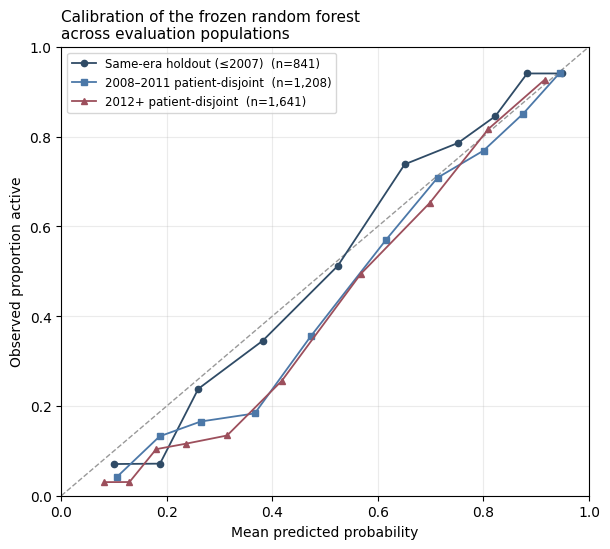

In [19]:
fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot([0, 1], [0, 1], color='#999999', lw=1, ls='--', zorder=1)

colours = {'Same-era holdout (≤2007)': '#2F4B66',
           '2008–2011 patient-disjoint': '#4C78A8',
           '2012+ patient-disjoint': '#9C4F5C'}

markers = {'Same-era holdout (≤2007)': 'o',
           '2008–2011 patient-disjoint': 's',
           '2012+ patient-disjoint': '^'}

for pop_name, frame in PRIMARY_POPULATIONS.items():
    y = frame[TARGET].to_numpy()
    p = FITTED[PRIMARY].predict_proba(frame[MODEL_FEATURES])[:, 1]
    q = pd.qcut(p, 10, labels=False, duplicates='drop')
    obs = [y[q == k].mean() for k in np.unique(q)]
    pred = [p[q == k].mean() for k in np.unique(q)]
    ax.plot(pred, obs, marker=markers[pop_name], ms=4.5, lw=1.3, color=colours[pop_name],
            label=f'{pop_name}  (n={len(frame):,})', zorder=3)

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed proportion active')
ax.set_title(f'Calibration of the frozen {PRIMARY.lower()}\nacross evaluation populations',
             loc='left', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8.5, loc='upper left', frameon=True)
ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig('figures/fig6_calibration_primary.png', dpi=300, bbox_inches='tight')
plt.show()

## C6. Sensitivity analysis — returning patients

The same frozen pipelines applied to the patients in each later period who also appear in
the earliest cohort. These populations are not patient-disjoint from the development data
and are therefore reported separately, as a check on whether the temporal pattern differs
when longitudinally continuing patients are included.

In [20]:
srows = []
for pop_name, frame in SENSITIVITY_POPULATIONS.items():
    for model_name, pipe in FITTED.items():
        r = evaluate(pipe, frame, BOOT[pop_name])
        srows.append({'Population': pop_name, 'Model': model_name,
                      'Pairs': len(frame), 'Patients': frame[GROUP].nunique(),
                      'Prevalence': round(r['prev'], 3),
                      'Mean predicted': round(r['meanpred'], 3),
                      'ROC-AUC [95% CI]': fmt(r['auc'], *r['auc_ci']),
                      'Brier skill [95% CI]': fmt(r['skill'], *r['skill_ci'])})

sensitivity_results = pd.DataFrame(srows)
sensitivity_results.to_csv('temporal_performance_sensitivity.csv', index=False)
print('Sensitivity analysis: returning-patient populations')
display(sensitivity_results)


Sensitivity analysis: returning-patient populations


,Population,Model,Pairs,Patients,Prevalence,Mean predicted,ROC-AUC [95% CI],Brier skill [95% CI]
0,2008–2011 returning patients,Logistic regression,2680,1059,0.484,0.508,"0.894 [0.879, 0.909]","0.413 [0.382, 0.441]"
1,2008–2011 returning patients,Random forest,2680,1059,0.484,0.502,"0.911 [0.897, 0.925]","0.513 [0.478, 0.546]"
2,2008–2011 returning patients,XGBoost,2680,1059,0.484,0.509,"0.910 [0.895, 0.924]","0.511 [0.475, 0.547]"
3,2012+ returning patients,Logistic regression,1430,796,0.408,0.459,"0.883 [0.861, 0.904]","0.370 [0.331, 0.407]"
4,2012+ returning patients,Random forest,1430,796,0.408,0.423,"0.883 [0.860, 0.904]","0.439 [0.391, 0.486]"
5,2012+ returning patients,XGBoost,1430,796,0.408,0.424,"0.880 [0.857, 0.901]","0.439 [0.385, 0.489]"


# Part D — Distributional shift across temporal populations

Distributional shift is assessed against the entire earliest temporal cohort. Because no fitted model is involved here, the reference is not restricted to the same-era holdout, and the later primary populations remain patient-disjoint from the full cohort by construction.

Shift is quantified using the population stability index (PSI) for all 12 predictors and the Kolmogorov-Smirnov (KS) statistic for continuous predictors. Bin edges and categories are defined from the reference population and held fixed across comparisons. Conventional PSI cut-offs are not applied, as they originate in credit-scoring practice rather than distributional theory. KS is reported as an effect size rather than converted into a significance test.

Shift is calculated from observed values only, with missingness reported separately, so imputed values do not influence the distributional comparison. Uncertainty is estimated using a patient-clustered bootstrap that resamples patients within both the reference and comparison populations in each replicate.

In [21]:
# D1. Populations and settings
from scipy.stats import ks_2samp

N_BINS, EPS, N_BOOT_PSI, PSI_SEED = 10, 1e-6, 1000, 3141

REFERENCE = earliest
LATER = {'2008\u20132011 patient-disjoint': populations['2008-2011']['new'],
         '2012+ patient-disjoint':          populations['2012+']['new']}
SENS = {'2008\u20132011 returning patients': populations['2008-2011']['returning'],
        '2012+ returning patients':          populations['2012+']['returning']}

print(f'reference : earliest cohort  {len(REFERENCE):,} pairs, '
      f'{REFERENCE[GROUP].nunique():,} patients')
for n, s in LATER.items():
    print(f'later     : {n:28s} {len(s):,} pairs, {s[GROUP].nunique():,} patients')

reference : earliest cohort  3,364 pairs, 1,199 patients
later     : 2008–2011 patient-disjoint   1,208 pairs, 621 patients
later     : 2012+ patient-disjoint       1,641 pairs, 884 patients


In [22]:
# D2. Fixed bin definitions and shift statistics

# ---- fixed bin definitions, taken from the reference and never recomputed

def make_bins(ref, var):
    if var in MODEL_CONTINUOUS:
        q = np.unique(np.nanquantile(ref[var].dropna(), np.linspace(0, 1, N_BINS + 1)))
        q[0], q[-1] = -np.inf, np.inf
        return ('continuous', q)
    return ('categorical', np.array(sorted(ref[var].dropna().unique()), dtype=object))


BINS = {v: make_bins(REFERENCE, v) for v in MODEL_FEATURES}


def proportions(values, spec):
    kind, edges = spec
    v = pd.Series(values).dropna()
    if kind == 'continuous':
        counts = np.histogram(v.astype(float), bins=edges)[0]
    else:
        counts = np.array([(v == c).sum() for c in edges])
    return counts / max(counts.sum(), 1)


def psi(ref_vals, cmp_vals, spec):
    p, q = proportions(ref_vals, spec), proportions(cmp_vals, spec)
    p, q = np.clip(p, EPS, None), np.clip(q, EPS, None)
    return float(np.sum((q - p) * np.log(q / p)))

## D3. Descriptive distributions and missingness

The underlying values in clinical units, reported alongside the shift statistics so that
the magnitude of any change can be judged rather than inferred from an index.

In [23]:
# D3
def describe(frame):
    out = {}
    for v in MODEL_CONTINUOUS:
        s = frame[v].dropna()
        out[v] = f'{s.mean():.1f} ({s.std():.1f})'
    for v in MODEL_CATEGORICAL:
        s = frame[v].dropna()
        top = s.value_counts().idxmax()
        out[v] = f'{top}: {(s == top).mean()*100:.1f}%'
    return out


desc = pd.DataFrame({'Earliest cohort (reference)': describe(REFERENCE),
                     **{k: describe(v) for k, v in LATER.items()}})
miss = pd.DataFrame({'Earliest cohort (reference)':
                     (REFERENCE[MODEL_FEATURES].isna().mean() * 100).round(1),
                     **{k: (v[MODEL_FEATURES].isna().mean() * 100).round(1)
                        for k, v in LATER.items()}})
desc.index.name = miss.index.name = 'Predictor'
desc.to_csv('rq2_descriptive_distributions.csv')
miss.to_csv('rq2_missingness_by_population.csv')
print('\nPredictor distributions (mean (SD), or modal category)')
print(desc.to_string())
print('\nMissingness (%)')
print(miss.to_string())


Predictor distributions (mean (SD), or modal category)
                  Earliest cohort (reference) 2008–2011 patient-disjoint 2012+ patient-disjoint
Predictor                                                                                      
agefu                             58.8 (14.7)                60.0 (14.6)            60.9 (14.0)
disease_duration                    4.2 (3.0)                  8.0 (7.4)              8.1 (7.0)
bmi                                27.7 (5.5)                 28.1 (5.7)             28.1 (5.5)
tend_28jt                           6.1 (8.2)                  5.9 (8.0)              4.6 (7.1)
swollen_28jt                        3.2 (4.5)                  2.8 (4.3)              2.2 (3.7)
esr_score                         27.9 (22.7)                27.4 (22.9)            16.4 (17.0)
Days_on_Steroids                198.2 (546.5)             375.8 (1272.6)          246.3 (915.4)
Days_on_DMARDs                  721.8 (935.6)            1410.3 (2334.0)        

## D4. Distributional shift with bootstrap intervals

Population stability index for every predictor, and the Kolmogorov-Smirnov statistic for
the continuous ones, each measured against the earliest cohort.

In [24]:
#  D3-D5 PSI, KS and bootstrap intervals
def patient_blocks(frame):
    return [np.flatnonzero((frame[GROUP] == p).to_numpy())
            for p in frame[GROUP].unique()]


REF_BLOCKS = patient_blocks(REFERENCE)
rows = []
for pop_name, frame in LATER.items():
    blocks = patient_blocks(frame)
    rng = np.random.default_rng(PSI_SEED)
    ref_arr = {v: REFERENCE[v].to_numpy() for v in MODEL_FEATURES}
    cmp_arr = {v: frame[v].to_numpy() for v in MODEL_FEATURES}

    boot = {v: [] for v in MODEL_FEATURES}
    for _ in range(N_BOOT_PSI):
        ri = np.concatenate([REF_BLOCKS[i] for i in
                             rng.integers(0, len(REF_BLOCKS), len(REF_BLOCKS))])
        ci = np.concatenate([blocks[i] for i in
                             rng.integers(0, len(blocks), len(blocks))])
        for v in MODEL_FEATURES:
            boot[v].append(psi(ref_arr[v][ri], cmp_arr[v][ci], BINS[v]))

    for v in MODEL_FEATURES:
        b = np.array(boot[v])
        ks = (ks_2samp(REFERENCE[v].dropna(), frame[v].dropna()).statistic
              if v in MODEL_CONTINUOUS else np.nan)
        rows.append({'Population': pop_name, 'Predictor': v,
                     'Type': 'continuous' if v in MODEL_CONTINUOUS else 'categorical',
                     'PSI': round(psi(ref_arr[v], cmp_arr[v], BINS[v]), 3),
                     'PSI 95% CI': f'[{np.percentile(b, 2.5):.3f}, '
                                   f'{np.percentile(b, 97.5):.3f}]',
                     'KS': round(ks, 3) if not np.isnan(ks) else ''})

shift = pd.DataFrame(rows)
shift.to_csv('rq2_distributional_shift.csv', index=False)
for pop_name in LATER:
    sub = shift[shift.Population == pop_name].sort_values('PSI', ascending=False)
    print(f'\nDistributional shift vs earliest cohort: {pop_name}')
    print(sub[['Predictor', 'Type', 'PSI', 'PSI 95% CI', 'KS']].to_string(index=False))


Distributional shift vs earliest cohort: 2008–2011 patient-disjoint
        Predictor        Type   PSI     PSI 95% CI     KS
 disease_duration  continuous 0.417 [0.318, 0.559]  0.259
comorbidity_count  continuous 0.273 [0.178, 0.406]  0.242
   Days_on_DMARDs  continuous 0.144 [0.099, 0.222]  0.128
        esr_score  continuous 0.096 [0.064, 0.174]  0.092
               sc categorical 0.050 [0.023, 0.130]       
     swollen_28jt  continuous 0.025 [0.009, 0.063]   0.07
            agefu  continuous 0.019 [0.015, 0.080]  0.049
 biologic_exposed categorical 0.019 [0.002, 0.055]       
        tend_28jt  continuous 0.015 [0.009, 0.048]   0.03
              bmi  continuous 0.014 [0.011, 0.064]  0.044
 Days_on_Steroids  continuous 0.008 [0.002, 0.040]  0.048
           gender categorical 0.002 [0.000, 0.024]       

Distributional shift vs earliest cohort: 2012+ patient-disjoint
        Predictor        Type   PSI     PSI 95% CI     KS
        esr_score  continuous 0.788 [0.663, 0.954]  0.

## D5. Ranked summary figure

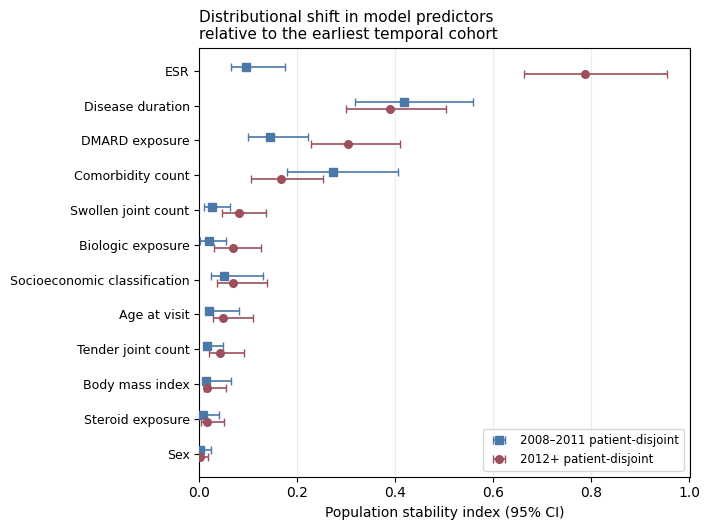

In [25]:
# D5 ranked figure
LABELS = {
    'agefu': 'Age at visit',
    'disease_duration': 'Disease duration',
    'bmi': 'Body mass index',
    'tend_28jt': 'Tender joint count',
    'swollen_28jt': 'Swollen joint count',
    'esr_score': 'ESR',
    'Days_on_Steroids': 'Steroid exposure',
    'Days_on_DMARDs': 'DMARD exposure',
    'comorbidity_count': 'Comorbidity count',
    'gender': 'Sex',
    'sc': 'Socioeconomic classification',
    'biologic_exposed': 'Biologic exposure'
}

order = (shift[shift.Population == '2012+ patient-disjoint']
         .sort_values('PSI', ascending=False)
         .Predictor.tolist())

y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(7.2, 5.4))

for pop_name, colour, marker, offset in [
        ('2008–2011 patient-disjoint', '#4C78A8', 's', -0.10),
        ('2012+ patient-disjoint', '#9C4F5C', 'o', 0.10)]:

    sub = (shift[shift.Population == pop_name]
           .set_index('Predictor')
           .loc[order])

    ci = sub['PSI 95% CI'].str.extract(
        r'\[([0-9.]+), ([0-9.]+)\]'
    ).astype(float)

    p = sub['PSI'].to_numpy()

    ax.errorbar(
        p,
        y + offset,
        xerr=np.vstack([
            p - ci[0].to_numpy(),
            ci[1].to_numpy() - p
        ]),
        fmt=marker,
        ms=5.5,
        color=colour,
        ecolor=colour,
        elinewidth=1.2,
        capsize=3,
        label=pop_name,
        zorder=3
    )

ax.set_yticks(y)
ax.set_yticklabels([LABELS[p] for p in order], fontsize=9)
ax.invert_yaxis()

ax.set_xlabel('Population stability index (95% CI)')

ax.set_title(
    'Distributional shift in model predictors\n'
    'relative to the earliest temporal cohort',
    loc='left',
    fontsize=11
)

ax.set_xlim(left=0)
ax.legend(fontsize=8.5)
ax.grid(axis='x', alpha=.25)

plt.tight_layout()

plt.savefig(
    'figures/fig7_predictor_shift.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## D6. Sensitivity — returning patients

The same statistics computed for the patients in each later period who also appear in the
earliest cohort. These are not independent of the reference population, so they are
reported as a decomposition rather than as a measure of population change.

In [26]:
#  D7 returning sensitivity
srows = []
for pop_name, frame in SENS.items():
    for v in MODEL_FEATURES:
        srows.append({'Population': pop_name, 'Predictor': v,
                      'PSI': round(psi(REFERENCE[v].to_numpy(),
                                       frame[v].to_numpy(), BINS[v]), 3)})
sens = pd.DataFrame(srows).pivot(index='Predictor', columns='Population', values='PSI')
new_psi = shift.pivot(index='Predictor', columns='Population', values='PSI')
combined = new_psi.join(sens).loc[order[::-1]]
combined.to_csv('rq2_shift_sensitivity.csv')
print('\nPSI vs earliest cohort: new versus returning patients')
print(combined.to_string())


PSI vs earliest cohort: new versus returning patients
Population         2008–2011 patient-disjoint  2012+ patient-disjoint  2008–2011 returning patients  2012+ returning patients
Predictor                                                                                                                    
gender                                  0.002                   0.001                         0.001                     0.001
Days_on_Steroids                        0.008                   0.015                         0.029                     0.047
bmi                                     0.014                   0.015                         0.012                     0.011
tend_28jt                               0.015                   0.042                         0.028                     0.153
agefu                                   0.019                   0.048                         0.028                     0.205
sc                                      0.050                  

## Part E — Explanation stability

SHAP explanations are computed for the frozen random forest across the same evaluation populations used for temporal performance analysis. Interventional TreeSHAP is applied on the probability scale using a fixed background of 100 development observations, keeping the model and reference distribution constant across populations.

One-hot encoded columns are aggregated back to the 12 conceptual predictors, so that a predictor is not credited with greater importance for occupying more encoded columns. An additivity check confirms that the base value plus the summed contributions reconstructs the predicted probability.

Global importance is summarised using mean absolute SHAP values, attribution shares and feature ranks. Temporal stability is assessed using Spearman rank correlation and top-five overlap.

As a benchmark for variation due to stochastic model fitting, the random forest is refitted 25 times on the same development data with only the random seed varied, and SHAP rankings are recomputed on the fixed same-era holdout. The resulting pairwise correlations are reported descriptively as a refitting noise floor.

In [27]:
# CODE CELL — E1. Attributions on the three primary populations
import shap
from scipy.stats import spearmanr
N_BACKGROUND, N_BOOT_SHAP, SHAP_SEED, N_REFITS = 100, 1000, 5150, 25

EXPLAIN = {'Same-era holdout (\u22642007)': holdout,
           '2008\u20132011 patient-disjoint': populations['2008-2011']['new'],
           '2012+ patient-disjoint':          populations['2012+']['new']}
BASE = 'Same-era holdout (\u22642007)'

pipe = FITTED[PRIMARY]
prep, model = pipe.named_steps['prep'], pipe.named_steps['model']
tcols = list(prep.get_feature_names_out())

# map each transformed column back to its original predictor
OWNER = []
for c in tcols:
    hit = [v for v in MODEL_FEATURES if c == v or c.startswith(v + '_')]
    OWNER.append(max(hit, key=len))
OWNER = np.array(OWNER)
print(f'{len(tcols)} transformed columns from {len(MODEL_FEATURES)} predictors')
for v in MODEL_FEATURES:
    n = int((OWNER == v).sum())
    if n > 1:
        print(f'  {v} spans {n} columns')

X_dev = prep.transform(development[MODEL_FEATURES])
rng = np.random.default_rng(SEED)
BACKGROUND = X_dev[rng.choice(len(X_dev), N_BACKGROUND, replace=False)]
print(f'fixed background: {N_BACKGROUND} development observations')


def aggregate(sv_pos):
    """Sum signed contributions of transformed columns per original predictor."""
    return np.column_stack([sv_pos[:, OWNER == v].sum(axis=1) for v in MODEL_FEATURES])


def row_shap(fitted_model, frame, background, check=False):
    X = prep.transform(frame[MODEL_FEATURES])
    ex = shap.TreeExplainer(fitted_model, data=background,
                            feature_perturbation='interventional',
                            model_output='probability')
    sv = np.array(ex.shap_values(X))
    pos = sv[:, :, 1] if sv.ndim == 3 else sv
    ev = ex.expected_value[1] if np.ndim(ex.expected_value) else ex.expected_value
    if check:
        recon = ev + pos.sum(1)
        pred = fitted_model.predict_proba(X)[:, 1]
        err = np.abs(recon - pred).max()
        assert err < 1e-5, f'additivity violated: {err:.2e}'
        print(f'  additivity check passed (max error {err:.2e})')
    return aggregate(pos)


SHAP_ROWS = {}
for name, frame in EXPLAIN.items():
    print(f'explaining {name} ({len(frame):,} rows)')
    SHAP_ROWS[name] = row_shap(model, frame, BACKGROUND, check=(name == BASE))

joblib.dump({'shap': SHAP_ROWS, 'features': MODEL_FEATURES}, 'shap_primary.joblib')

17 transformed columns from 12 predictors
  sc spans 6 columns
fixed background: 100 development observations
explaining Same-era holdout (≤2007) (841 rows)


 99%|===================| 1671/1682 [01:54<00:00]        

  additivity check passed (max error 3.05e-08)
explaining 2008–2011 patient-disjoint (1,208 rows)


100%|===================| 2412/2416 [02:48<00:00]        

explaining 2012+ patient-disjoint (1,641 rows)


100%|===================| 3268/3282 [03:47<00:00]        

['shap_primary.joblib']

In [28]:
# CODE CELL — E2. Global importance, share and rank
#  E2 global importance and rank
def importance(mat):
    m = np.abs(mat).mean(axis=0)
    return pd.Series(m, index=MODEL_FEATURES)


imp = pd.DataFrame({k: importance(v) for k, v in SHAP_ROWS.items()})
share = imp / imp.sum()
rank = imp.rank(ascending=False).astype(int)

tab = pd.concat({'mean |SHAP|': imp.round(4), 'share %': (share * 100).round(1),
                 'rank': rank}, axis=1)
tab = tab.loc[imp[BASE].sort_values(ascending=False).index]
tab.to_csv('rq3_global_importance.csv')
print('\nGlobal importance of the frozen random forest')
print(tab.to_string())


Global importance of the frozen random forest
                               mean |SHAP|                                                                    share %                                                                       rank                                                  
                  Same-era holdout (≤2007) 2008–2011 patient-disjoint 2012+ patient-disjoint Same-era holdout (≤2007) 2008–2011 patient-disjoint 2012+ patient-disjoint Same-era holdout (≤2007) 2008–2011 patient-disjoint 2012+ patient-disjoint
tend_28jt                           0.1934                     0.1883                 0.1889                     46.3                       43.3                   41.9                        1                          1                      1
esr_score                           0.0733                     0.0931                 0.1111                     17.6                       21.4                   24.6                        2                          2     

In [29]:
# CODE CELL — E3. Ranking stability with bootstrap intervals
#  E3 stability with bootstrap CIs
def blocks(frame):
    return [np.flatnonzero((frame[GROUP] == p).to_numpy())
            for p in frame[GROUP].unique()]


BLOCKS = {k: blocks(v) for k, v in EXPLAIN.items()}


def top_k_overlap(a, b, k=5):
    return len(set(a.nlargest(k).index) & set(b.nlargest(k).index))


rows = []
rng = np.random.default_rng(SHAP_SEED)
for later in [k for k in EXPLAIN if k != BASE]:
    rho = spearmanr(imp[BASE], imp[later]).statistic
    ov = top_k_overlap(imp[BASE], imp[later])
    br, bo = [], []
    for _ in range(N_BOOT_SHAP):
        bi = np.concatenate([BLOCKS[BASE][i] for i in
                             rng.integers(0, len(BLOCKS[BASE]), len(BLOCKS[BASE]))])
        li = np.concatenate([BLOCKS[later][i] for i in
                             rng.integers(0, len(BLOCKS[later]), len(BLOCKS[later]))])
        a = importance(SHAP_ROWS[BASE][bi])
        b = importance(SHAP_ROWS[later][li])
        br.append(spearmanr(a, b).statistic)
        bo.append(top_k_overlap(a, b))
    rows.append({'Comparison': f'{BASE} vs {later}',
                 'Spearman rho': round(rho, 3),
                 'rho 95% CI': f'[{np.percentile(br, 2.5):.3f}, '
                               f'{np.percentile(br, 97.5):.3f}]',
                 'Top-5 overlap': f'{ov}/5',
                 'Top-5 95% CI': f'[{np.percentile(bo, 2.5):.0f}, '
                                 f'{np.percentile(bo, 97.5):.0f}]'})

stability = pd.DataFrame(rows)
stability.to_csv('rq3_ranking_stability.csv', index=False)
print('\nExplanation ranking stability across temporal populations')
print(stability.to_string(index=False))


Explanation ranking stability across temporal populations
                                            Comparison  Spearman rho     rho 95% CI Top-5 overlap Top-5 95% CI
Same-era holdout (≤2007) vs 2008–2011 patient-disjoint         0.993 [0.951, 1.000]           5/5       [5, 5]
    Same-era holdout (≤2007) vs 2012+ patient-disjoint         0.979 [0.965, 1.000]           5/5       [5, 5]


## E4. Refit noise floor

The population is held fixed at the same-era holdout while the model is refitted under
different random seeds. Hyperparameters, preprocessing, development data and background
sample are unchanged; only the seed varies. This measures stochastic refitting variability,
not model-selection variability, and the models are not retuned.

In [30]:
RF_PARAMS = FITTED[PRIMARY].named_steps['model'].get_params()
RF_PARAMS.pop('random_state', None)
X_dev = prep.transform(development[MODEL_FEATURES])

In [31]:
#  E4 refit noise floor
print(f'\nnoise floor: {N_REFITS} refits on the development subset')
floor_imp = []
for s in range(N_REFITS):
    m = RandomForestClassifier(random_state=1000 + s, **RF_PARAMS)
    m.fit(X_dev, development[TARGET].to_numpy())
    floor_imp.append(importance(row_shap(m, EXPLAIN[BASE], BACKGROUND)))
    if (s + 1) % 5 == 0:
        print(f'  {s + 1}/{N_REFITS}')

pairwise = [spearmanr(floor_imp[i], floor_imp[j]).statistic
            for i in range(N_REFITS) for j in range(i + 1, N_REFITS)]
pairwise = np.array(pairwise)
floor = pd.DataFrame([{'Refits': N_REFITS, 'Pairwise comparisons': len(pairwise),
                       'Median rho': round(np.median(pairwise), 3),
                       'IQR': f'[{np.percentile(pairwise, 25):.3f}, '
                              f'{np.percentile(pairwise, 75):.3f}]',
                       'Range': f'[{pairwise.min():.3f}, {pairwise.max():.3f}]'}])
floor.to_csv('rq3_noise_floor.csv', index=False)
np.save('rq3_noise_floor_rho.npy', pairwise)
print('\nRefit noise floor, population held fixed at the same-era holdout')
print(floor.to_string(index=False))


noise floor: 25 refits on the development subset


 99%|===================| 1673/1682 [01:54<00:00]        

  5/25


100%|===================| 1674/1682 [01:54<00:00]        

  10/25


...

  15/25


100%|===================| 1677/1682 [01:53<00:00]        

  20/25


100%|===================| 1675/1682 [01:52<00:00]        

  25/25

Refit noise floor, population held fixed at the same-era holdout
 Refits  Pairwise comparisons  Median rho            IQR          Range
     25                   300       0.993 [0.991, 0.995] [0.986, 1.000]


## E5. Distributional shift and change in attribution

Whether predictors whose distributions shifted most also changed most in their relative
contribution to predictions. The stability index here is calculated against the same-era
holdout rather than the full earliest cohort, solely so that shift and attribution change
share the same baseline population; it does not replace the RQ2 results in Section 3.7,
which use the full earliest cohort as reference. Absolute change in attribution share is
preferred to change in rank, since a rank can move because a neighbouring predictor
crossed it even when the predictor's own contribution barely changed. The correlation
across twelve predictors is descriptive only.


Shift versus attribution change: 2008–2011 patient-disjoint   (Spearman across 12 predictors = 0.06, descriptive only)
        Predictor  PSI vs holdout  Attribution share change  Rank change
 disease_duration           0.346                      0.17            0
comorbidity_count           0.245                      0.32            0
   Days_on_DMARDs           0.142                      0.08            0
        esr_score           0.122                      3.84            0
               sc           0.046                      0.17           -1
              bmi           0.038                      0.24            0
 biologic_exposed           0.025                      0.02            0
        tend_28jt           0.025                      3.04            0
     swollen_28jt           0.022                      0.76            0
            agefu           0.021                      0.08            1
           gender           0.006                      0.37            0
 Day

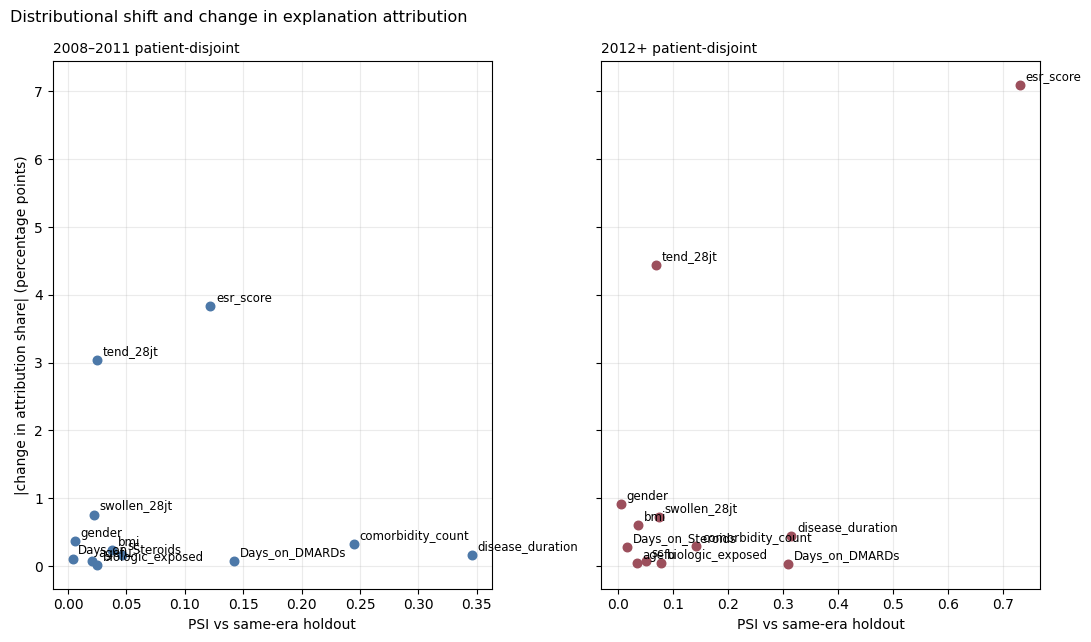


saved figures/fig8_shift_vs_attribution.png


In [32]:
# E5 linkage to distributional shift
N_BINS, EPS = 10, 1e-6


def make_bins(ref, var):
    if var in MODEL_CONTINUOUS:
        q = np.unique(np.nanquantile(ref[var].dropna(), np.linspace(0, 1, N_BINS + 1)))
        q[0], q[-1] = -np.inf, np.inf
        return ('continuous', q)
    return ('categorical', np.array(sorted(ref[var].dropna().unique()), dtype=object))


def props(values, spec):
    kind, edges = spec
    v = pd.Series(values).dropna()
    counts = (np.histogram(v.astype(float), bins=edges)[0] if kind == 'continuous'
              else np.array([(v == c).sum() for c in edges]))
    return counts / max(counts.sum(), 1)


def psi(a, b, spec):
    p, q = np.clip(props(a, spec), EPS, None), np.clip(props(b, spec), EPS, None)
    return float(np.sum((q - p) * np.log(q / p)))


BINS_H = {v: make_bins(holdout, v) for v in MODEL_FEATURES}
link_rows = []
for later in [k for k in EXPLAIN if k != BASE]:
    for v in MODEL_FEATURES:
        link_rows.append({
            'Population': later, 'Predictor': v,
            'PSI vs holdout': round(psi(holdout[v].to_numpy(),
                                        EXPLAIN[later][v].to_numpy(), BINS_H[v]), 3),
            'Attribution share change': round(abs(share.loc[v, later]
                                                  - share.loc[v, BASE]) * 100, 2),
            'Rank change': int(rank.loc[v, later] - rank.loc[v, BASE])})

link = pd.DataFrame(link_rows)
link.to_csv('rq3_shift_attribution_linkage.csv', index=False)
for later in [k for k in EXPLAIN if k != BASE]:
    sub = link[link.Population == later].sort_values('PSI vs holdout', ascending=False)
    r = spearmanr(sub['PSI vs holdout'], sub['Attribution share change']).statistic
    print(f'\nShift versus attribution change: {later}   (Spearman across 12 '
          f'predictors = {r:.2f}, descriptive only)')
    print(sub[['Predictor', 'PSI vs holdout', 'Attribution share change',
               'Rank change']].to_string(index=False))

link_colours = {
    '2008–2011 patient-disjoint': '#4C78A8',
    '2012+ patient-disjoint': '#9C4F5C'
}

fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)

for ax, later in zip(axes, [k for k in EXPLAIN if k != BASE]):
    sub = link[link.Population == later]

    ax.scatter(
        sub['PSI vs holdout'],
        sub['Attribution share change'],
        s=38,
        color=link_colours[later],
        zorder=3
    )
    
    for _, r_ in sub.iterrows():
        ax.annotate(r_.Predictor, (r_['PSI vs holdout'],
                                   r_['Attribution share change']),
                    fontsize=8.5, xytext=(4, 3), textcoords='offset points')
    ax.set_title(later, fontsize=10, loc='left')
    ax.set_xlabel('PSI vs same-era holdout')
    ax.grid(alpha=.25)
axes[0].set_ylabel('|change in attribution share| (percentage points)')
fig.suptitle('Distributional shift and change in explanation attribution',
             x=0.01, ha='left', fontsize=11.5)
plt.tight_layout()
plt.savefig('figures/fig8_shift_vs_attribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nsaved figures/fig8_shift_vs_attribution.png')

## E6. Sensitivity analyses

Two separate questions, answered in one table.

The first is sensitivity to the explanation formulation. The primary analysis uses
interventional TreeSHAP against a fixed background; this cell recomputes the same
comparisons for the random forest using path-dependent TreeSHAP, which handles feature
dependence differently and requires no background sample. Where the two agree, the
finding does not rest on that choice.

The second is sensitivity to the model architecture. Interventional TreeSHAP could not be
applied to the fitted XGBoost model under the installed SHAP and XGBoost versions because
of a library compatibility error. Architecture sensitivity is therefore assessed using
path-dependent TreeSHAP for both models, ensuring they are compared under the same
explanation formulation rather than confounding architecture with the choice of method.

Attribution shares are reported alongside the correlations because a stable ordering does
not imply unchanged reliance.

In [33]:
# CODE CELL — E6
from scipy.stats import spearmanr

interventional = dict(zip(stability['Comparison'], stability['Spearman rho']))

rows = []
for mname in ['Random forest', 'XGBoost']:
    pipe = FITTED[mname]
    pr = pipe.named_steps['prep']
    tc = list(pr.get_feature_names_out())
    own = np.array([max([v for v in MODEL_FEATURES
                         if c == v or c.startswith(v + '_')], key=len) for c in tc])

    I = {}
    for k, fr in EXPLAIN.items():
        X = pr.transform(fr[MODEL_FEATURES])
        ex = shap.TreeExplainer(pipe.named_steps['model'],
                                feature_perturbation='tree_path_dependent')
        sv = np.array(ex.shap_values(X))
        pos = sv[:, :, 1] if sv.ndim == 3 else sv
        agg = np.column_stack([pos[:, own == v].sum(1) for v in MODEL_FEATURES])
        I[k] = pd.Series(np.abs(agg).mean(0), index=MODEL_FEATURES)

    for later in [k for k in EXPLAIN if k != BASE]:
        key = f'{BASE} vs {later}'
        rows.append({
            'Model': mname,
            'Comparison': f'baseline vs {later}',
            'rho (path-dependent)': round(spearmanr(I[BASE], I[later]).statistic, 3),
            'rho (interventional)': (round(interventional[key], 3)
                                     if mname == PRIMARY and key in interventional
                                     else '\u2014'),
            'Top-5 overlap':
                f"{len(set(I[BASE].nlargest(5).index) & set(I[later].nlargest(5).index))}/5",
            'ESR share, baseline %': round(I[BASE]['esr_score'] / I[BASE].sum() * 100, 1),
            'ESR share, later %': round(I[later]['esr_score'] / I[later].sum() * 100, 1)})

architecture = pd.DataFrame(rows)
architecture.to_csv('rq3_sensitivity_analyses.csv', index=False)

print('Sensitivity analyses')
print('  formulation : random forest, interventional vs path-dependent')
print('  architecture: random forest vs XGBoost, both path-dependent')
display(architecture)

Sensitivity analyses
  formulation : random forest, interventional vs path-dependent
  architecture: random forest vs XGBoost, both path-dependent


,Model,Comparison,rho (path-dependent),rho (interventional),Top-5 overlap,"ESR share, baseline %","ESR share, later %"
0,Random forest,baseline vs 2008–2011 patient-disjoint,0.993,0.993,5/5,16.900000,20.8
1,Random forest,baseline vs 2012+ patient-disjoint,0.993,0.979,5/5,16.900000,24.5
2,XGBoost,baseline vs 2008–2011 patient-disjoint,0.993,—,5/5,16.799999,20.6
3,XGBoost,baseline vs 2012+ patient-disjoint,0.993,—,5/5,16.799999,24.5


In [34]:
import sys
from importlib.metadata import version
print('python', sys.version.split()[0])
for pkg in ['scikit-learn', 'numpy', 'pandas', 'scipy', 'xgboost',
            'shap', 'optuna', 'matplotlib', 'joblib']:
    print(pkg, version(pkg))

python 3.14.2
scikit-learn 1.8.0
numpy 2.4.4
pandas 3.0.2
scipy 1.17.1
xgboost 3.4.1
shap 0.52.0
optuna 4.9.0
matplotlib 3.10.8
joblib 1.5.3
